In [89]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer
%matplotlib inline

In [90]:
df = pd.read_csv('WineQT.csv')

Text(0.5, 1.0, 'Sebaran Nilai Fixed Acidity vs Volatile Acidity')

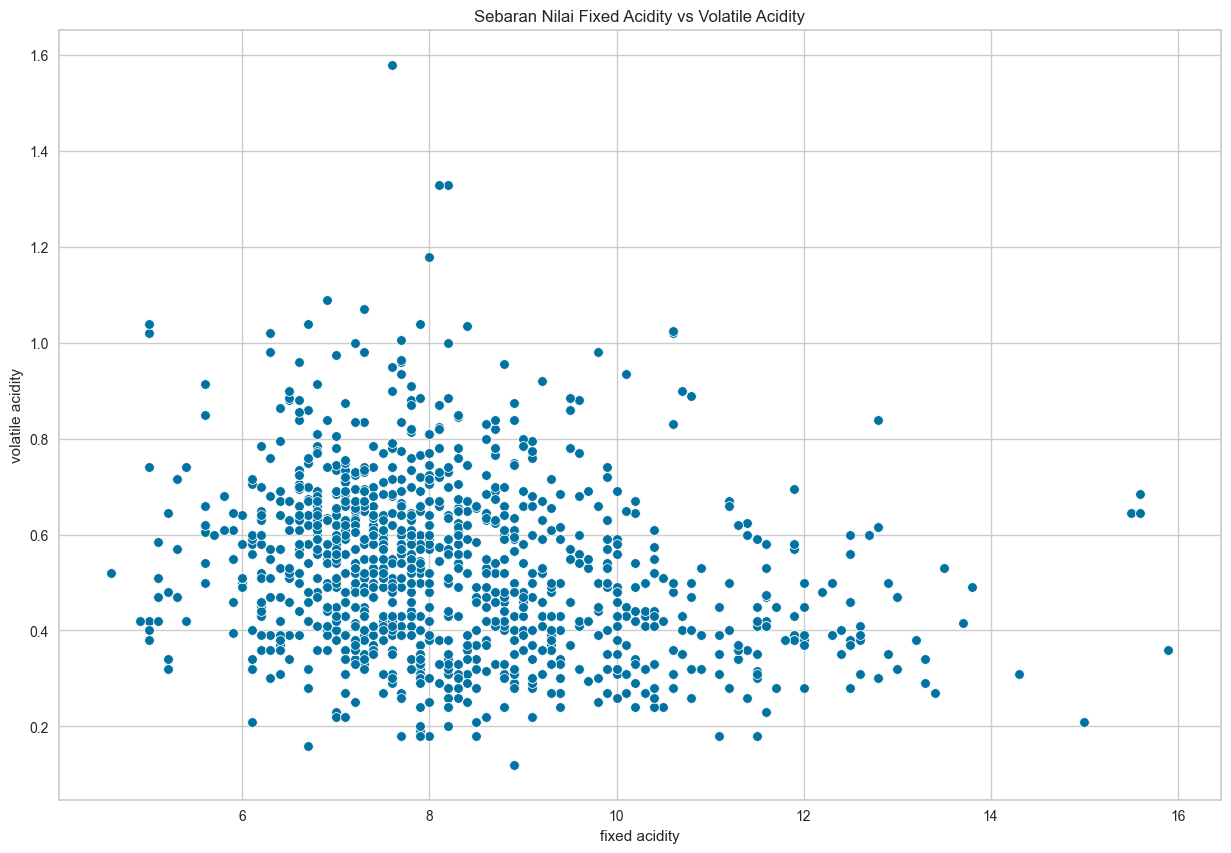

In [91]:
fig, ax = plt.subplots(figsize=(15,10))
sns.scatterplot(data=df, x='fixed acidity', y='volatile acidity')
plt.title('Sebaran Nilai Fixed Acidity vs Volatile Acidity')

In [92]:
df.describe()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


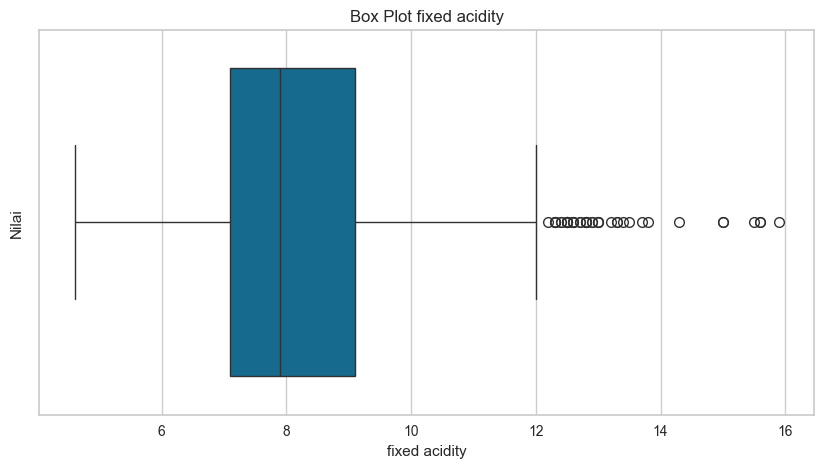

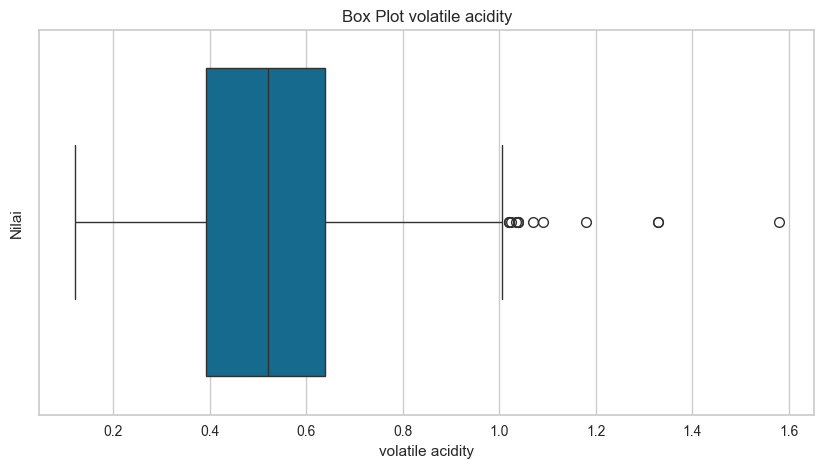

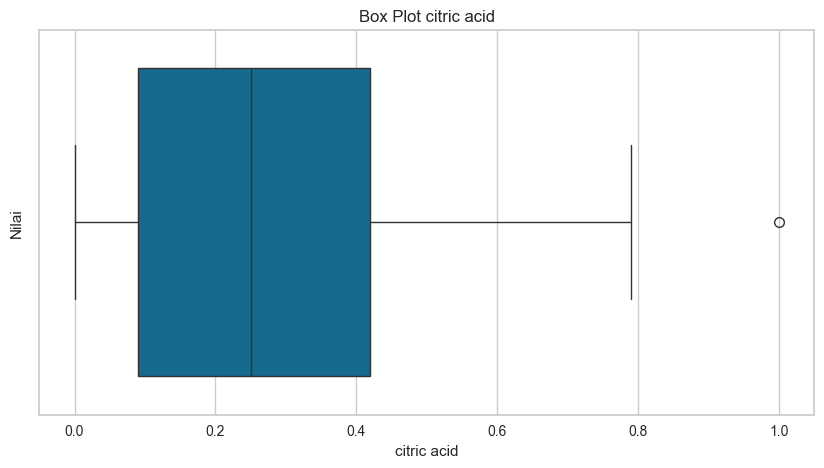

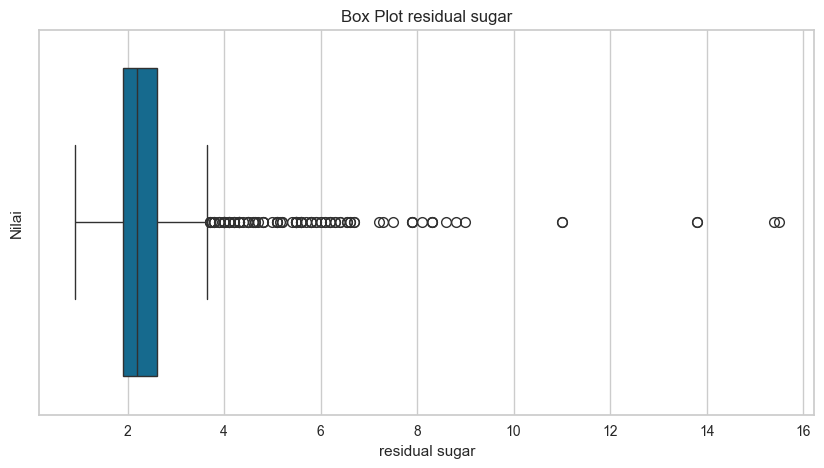

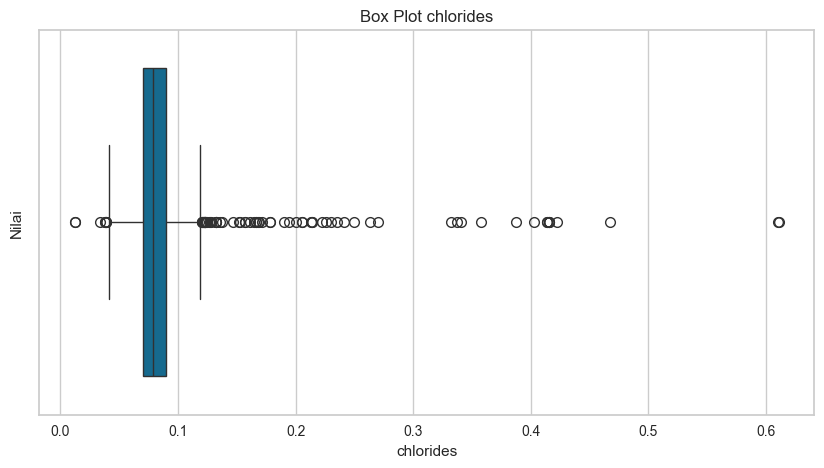

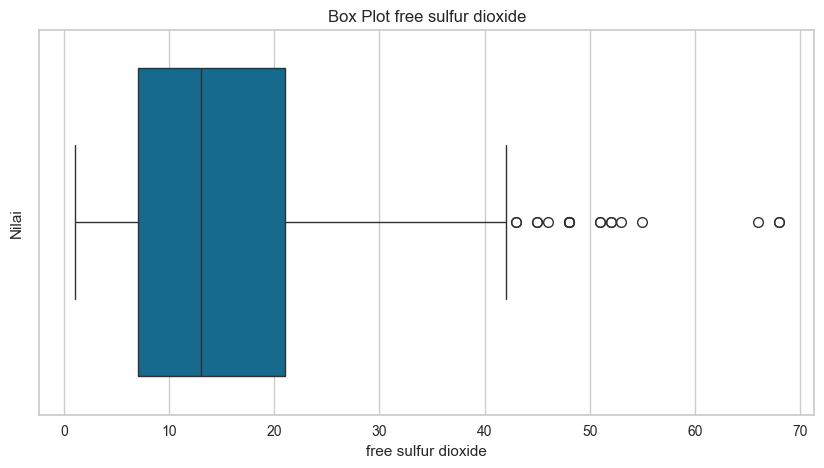

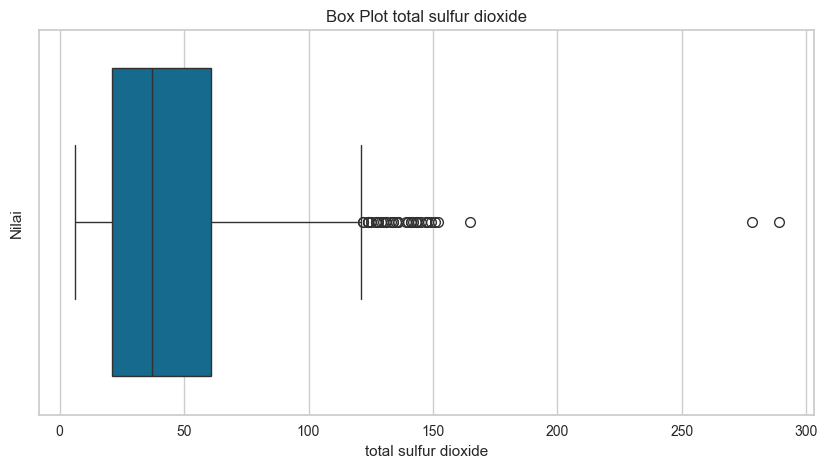

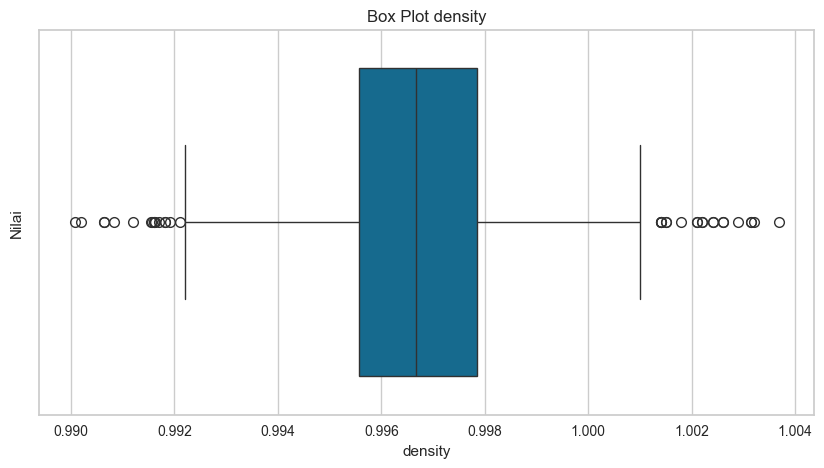

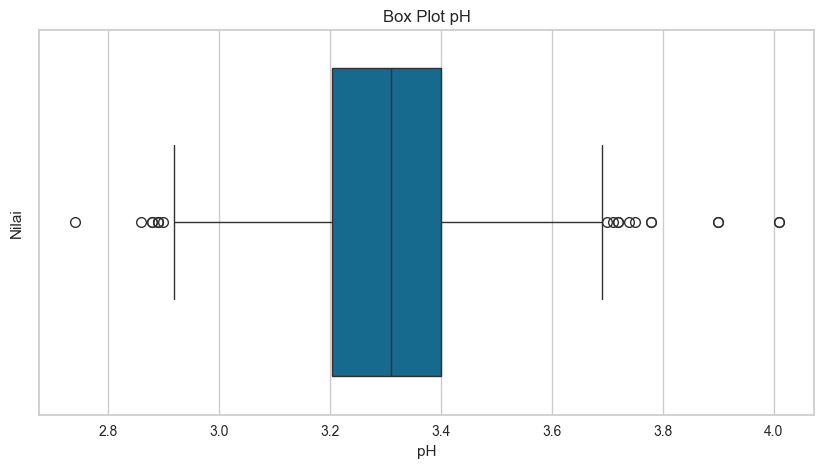

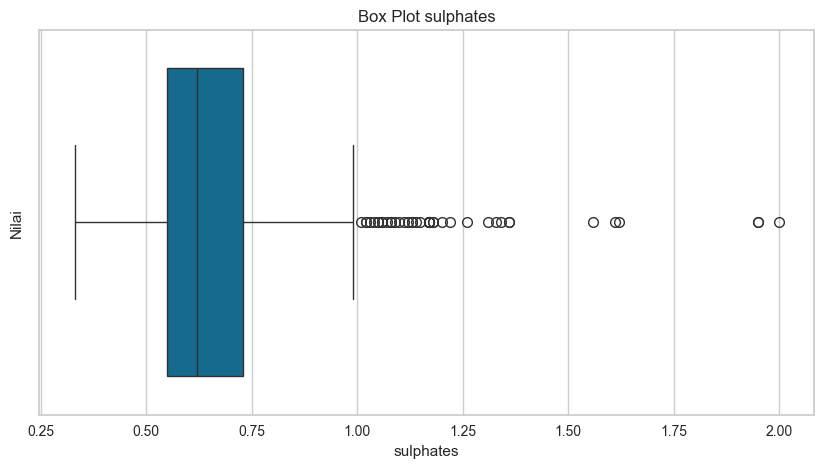

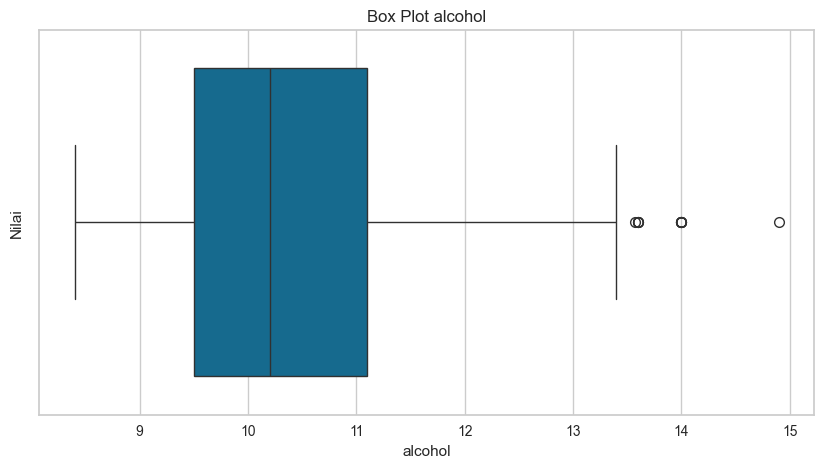

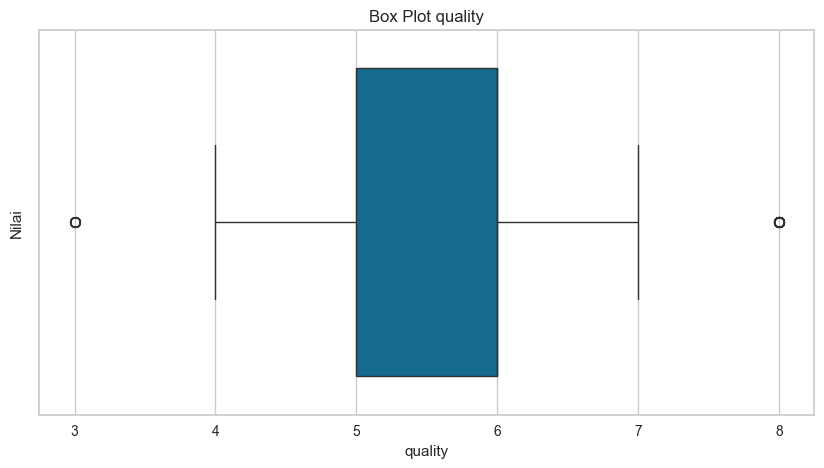

In [93]:
coll = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']

for col in coll:
    plt.figure(figsize=(10,5))
    sns.boxplot(x=df[col])
    plt.xlabel(col)
    plt.ylabel('Nilai')
    plt.title(f'Box Plot {col}')
    plt.show()

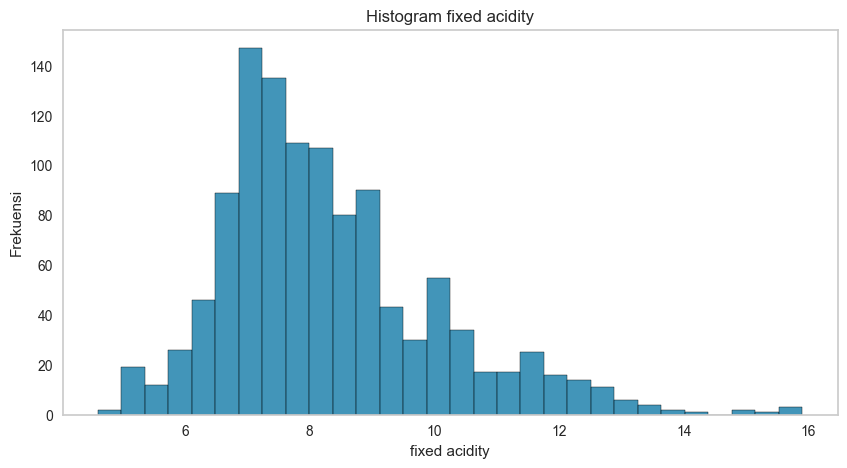

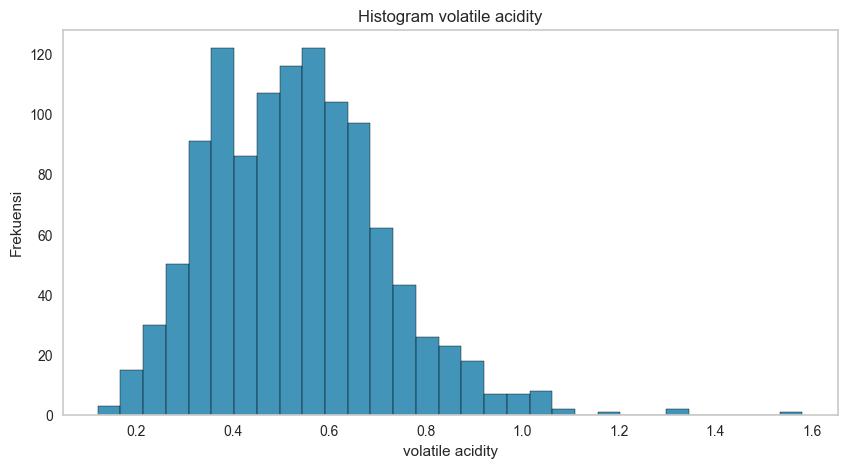

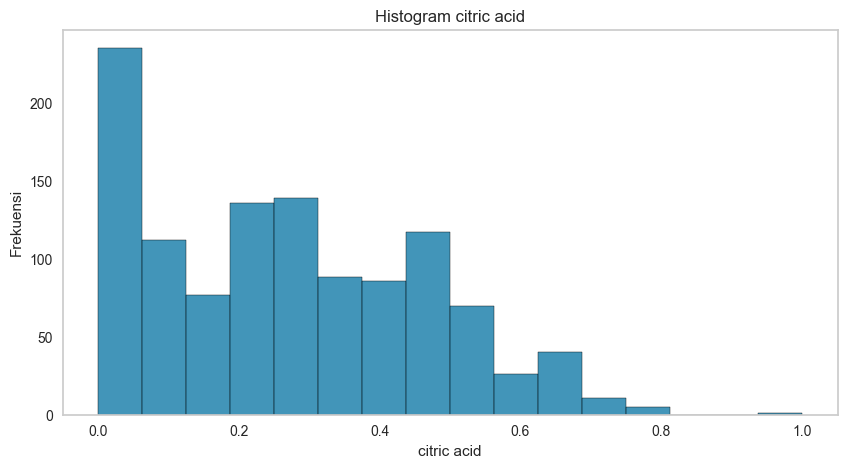

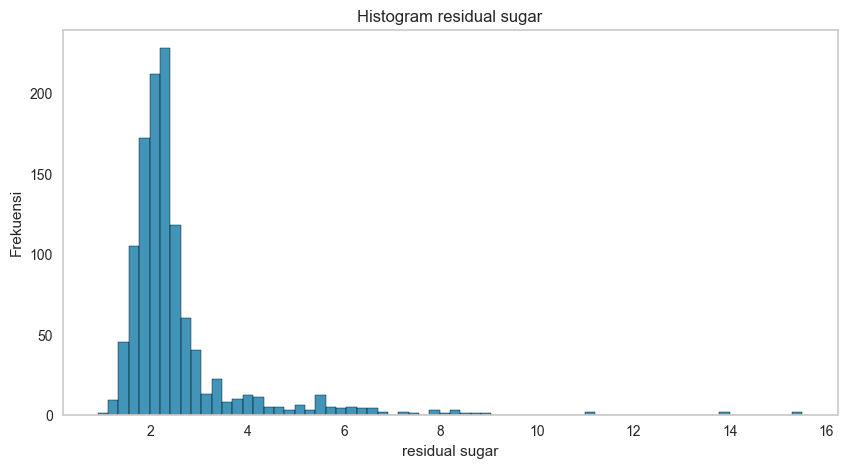

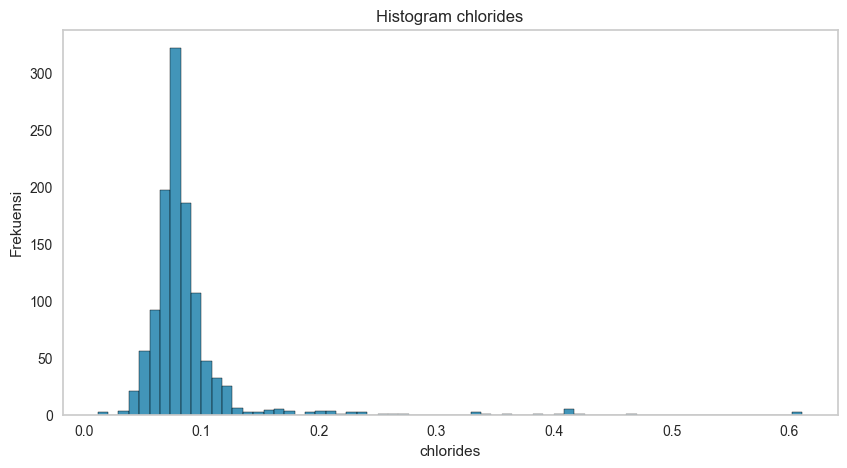

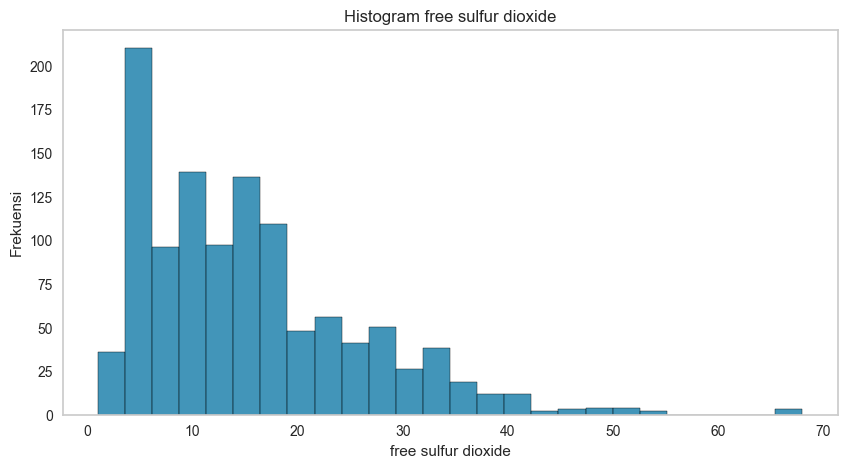

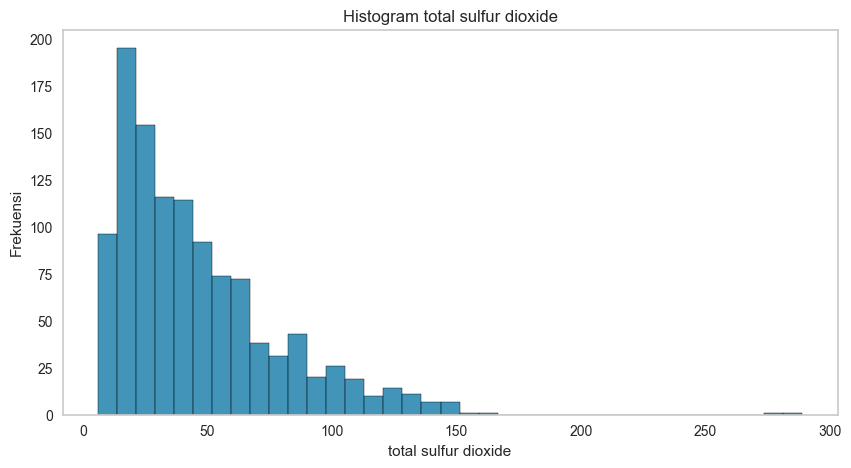

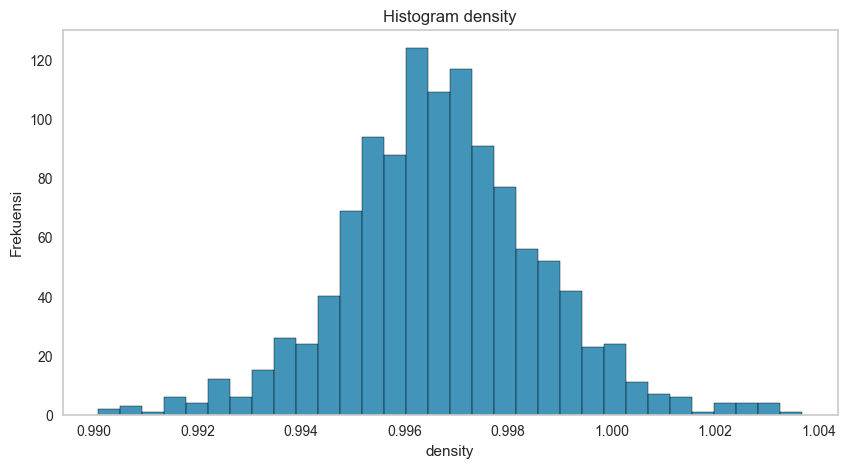

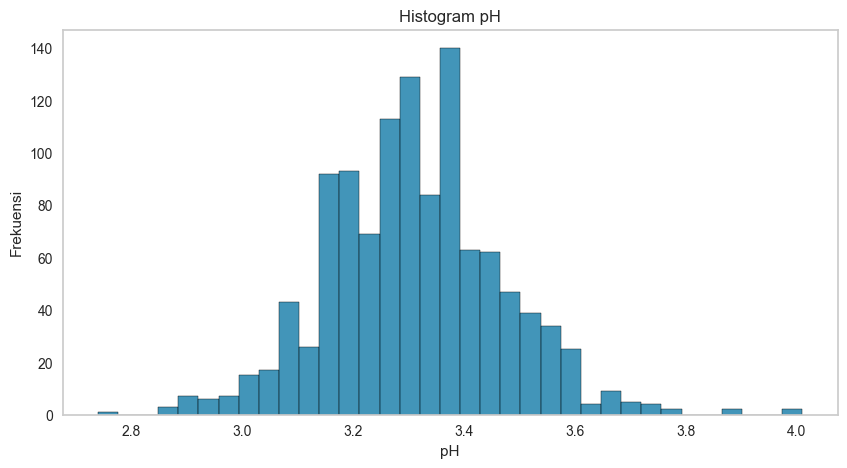

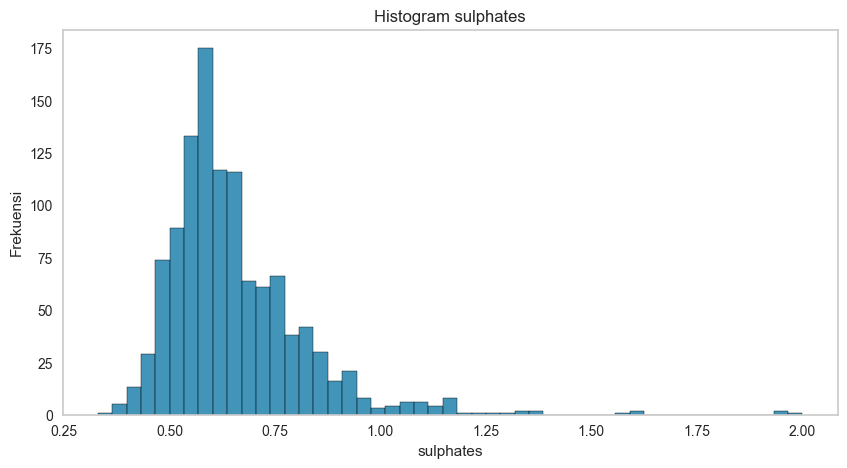

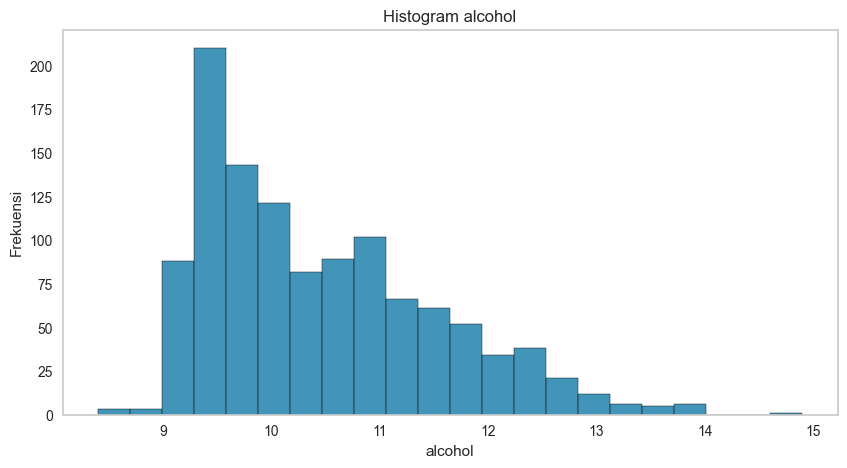

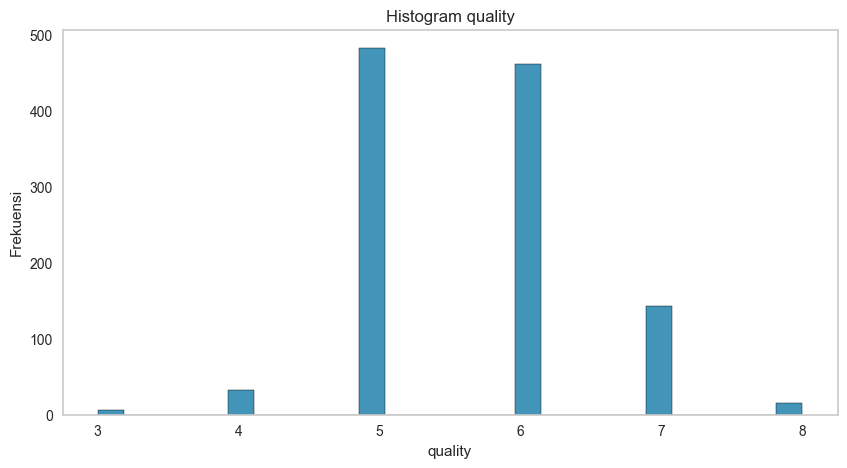

In [94]:
for col in coll:
    plt.figure(figsize=(10,5))
    sns.histplot(x=df[col], kde=False)
    plt.xlabel(col)
    plt.ylabel('Frekuensi')
    plt.title(f'Histogram {col}')
    plt.grid()
    plt.show()

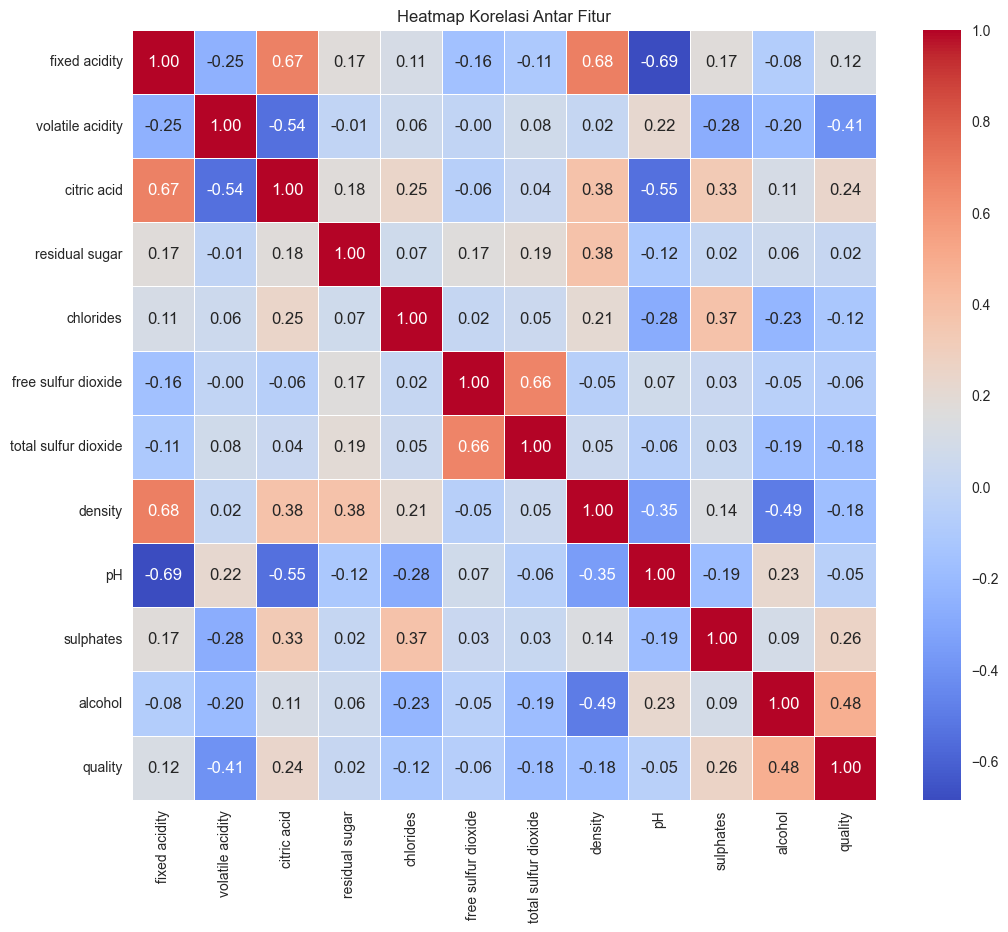

In [95]:
plt.figure(figsize=(12,10))
sns.heatmap(df[coll].corr(), annot=True, cmap='coolwarm', linewidths=0.5, linecolor='white', fmt='.2f')
plt.title('Heatmap Korelasi Antar Fitur')
plt.show()

In [96]:
print(f"Dataframe dimension before duplication drop {df.shape[0]}")

df = df.drop_duplicates().reset_index(drop=True)

print(f"Dataframe dimension after duplication drop {df.shape[0]}")

Dataframe dimension before duplication drop 1143
Dataframe dimension after duplication drop 1143


In [97]:
df = df.drop(columns=['Id'])

In [98]:
fitur_columns = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']
X = df[fitur_columns].values
y = df['quality'].values

In [99]:
X_std = StandardScaler().fit_transform(X)
df_scaled = pd.DataFrame(data= X_std, columns=fitur_columns)
df_scaled.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
count,1.143000e+03,1.143000e+03,1.143000e+03,1.143000e+03,1.143000e+03,1.143000e+03,1.143000e+03,1.143000e+03,1.143000e+03,1.143000e+03,1.143000e+03
mean,-3.729883e-16,4.475860e-16,2.486589e-17,1.554118e-16,8.081413e-17,-5.594825e-17,9.946355e-17,5.783805e-14,-8.454402e-16,4.973178e-17,-1.193563e-15
std,1.000438e+00,1.000438e+00,1.000438e+00,1.000438e+00,1.000438e+00,1.000438e+00,1.000438e+00,1.000438e+00,1.000438e+00,1.000438e+00,1.000438e+00
min,-2.124483e+00,-2.290883e+00,-1.365027e+00,-1.204252e+00,-1.585988e+00,-1.426458e+00,-1.218108e+00,-3.461348e+00,-3.646432e+00,-1.924024e+00,-1.887834e+00
25%,-6.933192e-01,-7.732388e-01,-9.072439e-01,-4.664214e-01,-3.583880e-01,-8.408632e-01,-7.603412e-01,-6.030539e-01,-6.769982e-01,-6.323694e-01,-8.709366e-01
50%,-2.353469e-01,-6.314838e-02,-9.340780e-02,-2.450722e-01,-1.678983e-01,-2.552689e-01,-2.720568e-01,-2.619819e-02,-6.480857e-03,-2.213884e-01,-2.238203e-01
75%,4.516116e-01,6.051720e-01,7.712930e-01,5.006018e-02,6.492241e-02,5.255235e-01,4.603699e-01,5.792404e-01,5.682483e-01,4.244390e-01,6.081863e-01
max,4.344377e+00,5.840349e+00,3.721449e+00,9.568078e+00,1.109216e+01,5.112679e+00,7.418423e+00,3.616827e+00,4.463634e+00,7.880809e+00,4.121103e+00


In [100]:
X_std

array([[-0.52157961,  0.93933222, -1.36502663, ...,  1.27069495,
        -0.57365783, -0.96338181],
       [-0.29259344,  1.94181282, -1.36502663, ..., -0.70892755,
         0.1308811 , -0.59360107],
       [-0.29259344,  1.27349242, -1.16156762, ..., -0.32577481,
        -0.04525363, -0.59360107],
       ...,
       [-1.20853813,  0.38239855, -0.9581086 , ...,  0.88754221,
        -0.45623467,  0.05351522],
       [-1.38027776,  0.10393172, -0.8563791 , ...,  1.33455374,
         0.60057372,  0.70063152],
       [-1.38027776,  0.6330187 , -0.75464959, ...,  1.65384769,
         0.30701583, -0.22382033]], shape=(1143, 11))

In [101]:
df_scaled

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,-0.521580,0.939332,-1.365027,-0.466421,-0.231395,-0.450467,-0.363610,0.555854,1.270695,-0.573658,-0.963382
1,-0.292593,1.941813,-1.365027,0.050060,0.234247,0.915920,0.643477,0.036165,-0.708928,0.130881,-0.593601
2,-0.292593,1.273492,-1.161568,-0.171289,0.107253,-0.060071,0.246745,0.140103,-0.325775,-0.045254,-0.593601
3,1.653789,-1.399789,1.483400,-0.466421,-0.252560,0.135127,0.429852,0.659792,-0.964363,-0.456235,-0.593601
4,-0.521580,0.939332,-1.365027,-0.466421,-0.231395,-0.450467,-0.363610,0.555854,1.270695,-0.573658,-0.963382
...,...,...,...,...,...,...,...,...,...,...,...
1138,-1.151292,-0.118842,-0.703785,-0.171289,-0.231395,1.306316,-0.180503,-0.514707,0.695966,0.541862,0.515741
1139,-0.865059,0.493785,-0.958109,-0.466421,-0.400719,1.208717,-0.241539,-0.114545,0.695966,0.952843,-0.870937
1140,-1.208538,0.382399,-0.958109,-0.392638,0.064922,1.599113,-0.058432,-0.951246,0.887542,-0.456235,0.053515
1141,-1.380278,0.103932,-0.856379,-0.245072,-0.527712,2.282306,0.155192,-0.836914,1.334554,0.600574,0.700632


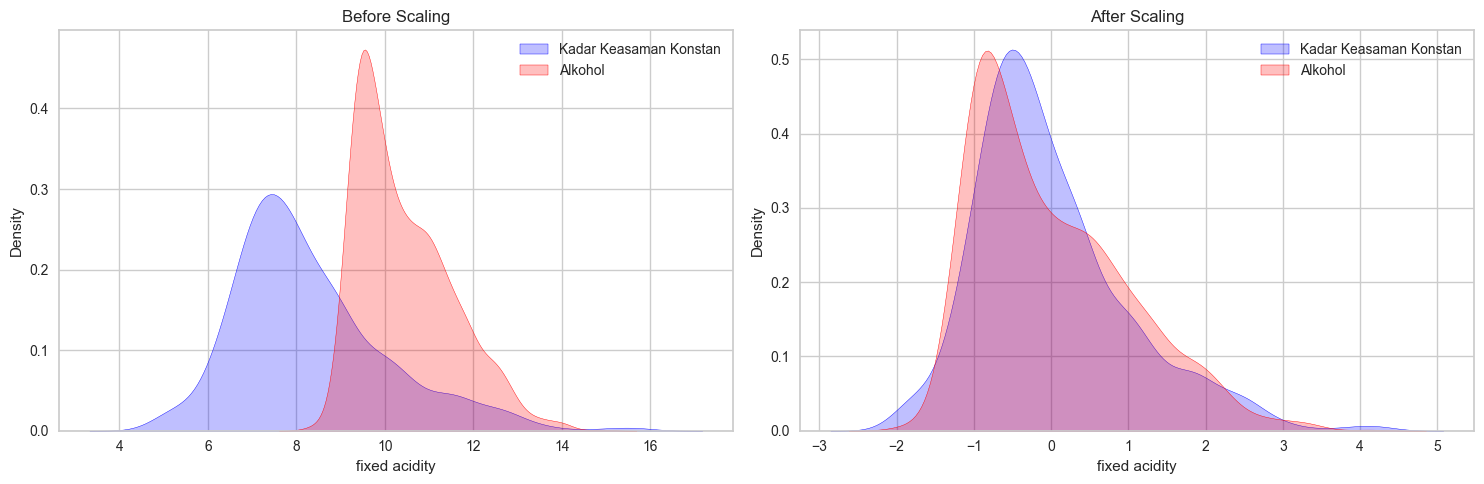

In [102]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

#before scaling
ax1.set_title('Before Scaling')
sns.kdeplot(df['fixed acidity'], ax=ax1, label='Kadar Keasaman Konstan', shade=True, color='blue', fill=True)
#sns.kdeplot(df['volatile acidity'], ax=ax1, label='Kadar Keasaman Volatil', shade=True, color='green', fill=True)
# sns.kdeplot(df['citric acid'], ax=ax1, label='Asam Sitrat', shade=True, color='orange', fill=True)
# sns.kdeplot(df['residual sugar'], ax=ax1, label='Gula Residu', shade=True, color='purple', fill=True)
# sns.kdeplot(df['chlorides'], ax=ax1, label='Klorida', shade=True, color='brown', fill=True)
# sns.kdeplot(df['free sulfur dioxide'], ax=ax1, label='Sulfur Dioksida Bebas', shade=True, color='cyan', fill=True)
# sns.kdeplot(df['total sulfur dioxide'], ax=ax1, label='Total Sulfur Dioksida', shade=True, color='magenta', fill=True)
# sns.kdeplot(df['density'], ax=ax1, label='Kerapatan', shade=True, color='yellow', fill=True)
# sns.kdeplot(df['pH'], ax=ax1, label='pH', shade=True, color='black', fill=True)
# sns.kdeplot(df['sulphates'], ax=ax1, label='Sulphates', shade=True, color='gray', fill=True)
sns.kdeplot(df['alcohol'], ax=ax1, label='Alkohol', shade=True, color='red', fill=True)
ax1.legend()

#after scaling
ax2.set_title('After Scaling')
sns.kdeplot(df_scaled['fixed acidity'], ax=ax2, label='Kadar Keasaman Konstan', shade=True, color='blue', fill=True)
#sns.kdeplot(df_scaled['volatile acidity'], ax=ax2, label='Kadar Keasaman Volatil', shade=True, color='green', fill=True)
#sns.kdeplot(df_scaled['citric acid'], ax=ax2, label='Asam Sitrat', shade=True, color='orange', fill=True)
# sns.kdeplot(df_scaled['residual sugar'], ax=ax2, label='Gula Residu', shade=True, color='purple', fill=True)
# sns.kdeplot(df_scaled['chlorides'], ax=ax2, label='Klorida', shade=True, color='brown', fill=True)
# sns.kdeplot(df_scaled['free sulfur dioxide'], ax=ax2, label='Sulfur Dioksida Bebas', shade=True, color='cyan', fill=True)
# sns.kdeplot(df_scaled['total sulfur dioxide'], ax=ax2, label='Total Sulfur Dioksida', shade=True, color='magenta', fill=True)
# sns.kdeplot(df_scaled['density'], ax=ax2, label='Kerapatan', shade=True, color='yellow', fill=True)
# sns.kdeplot(df_scaled['pH'], ax=ax2, label='pH', shade=True, color='black', fill=True)
# sns.kdeplot(df_scaled['sulphates'], ax=ax2, label='Sulphates', shade=True, color='gray', fill=True)
sns.kdeplot(df_scaled['alcohol'], ax=ax2, label='Alkohol', shade=True, color='red', fill=True)
ax2.legend()

plt.tight_layout()
plt.show()

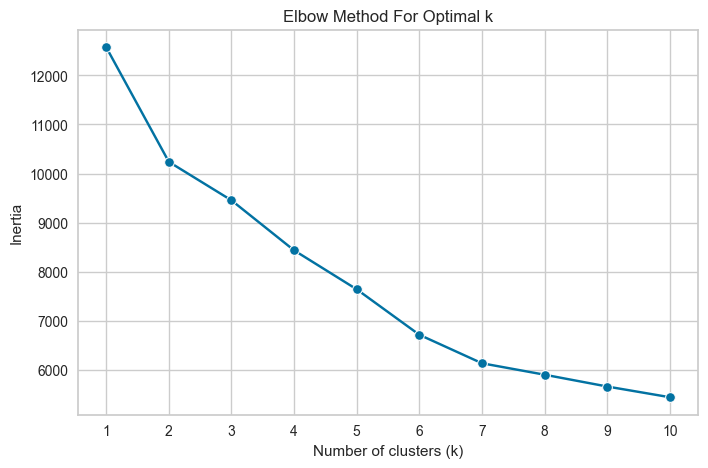

In [103]:
inertia = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=0)
    kmeans.fit(df_scaled.values)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.title('Elbow Method For Optimal k')
sns.lineplot(x=range(1, 11), y=inertia, marker='o')
sns.scatterplot(x=range(1, 11), y=inertia, color='red')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

In [104]:
kmeans = KMeans(n_clusters=5, random_state=0)
kmeans.fit(df_scaled.values)

df_scaled['Cluster'] = kmeans.labels_
df_scaled.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,Cluster
0,-0.521580,0.939332,-1.365027,-0.466421,-0.231395,-0.450467,-0.363610,0.555854,1.270695,-0.573658,-0.963382,4
1,-0.292593,1.941813,-1.365027,0.050060,0.234247,0.915920,0.643477,0.036165,-0.708928,0.130881,-0.593601,3
2,-0.292593,1.273492,-1.161568,-0.171289,0.107253,-0.060071,0.246745,0.140103,-0.325775,-0.045254,-0.593601,4
3,1.653789,-1.399789,1.483400,-0.466421,-0.252560,0.135127,0.429852,0.659792,-0.964363,-0.456235,-0.593601,2
4,-0.521580,0.939332,-1.365027,-0.466421,-0.231395,-0.450467,-0.363610,0.555854,1.270695,-0.573658,-0.963382,4


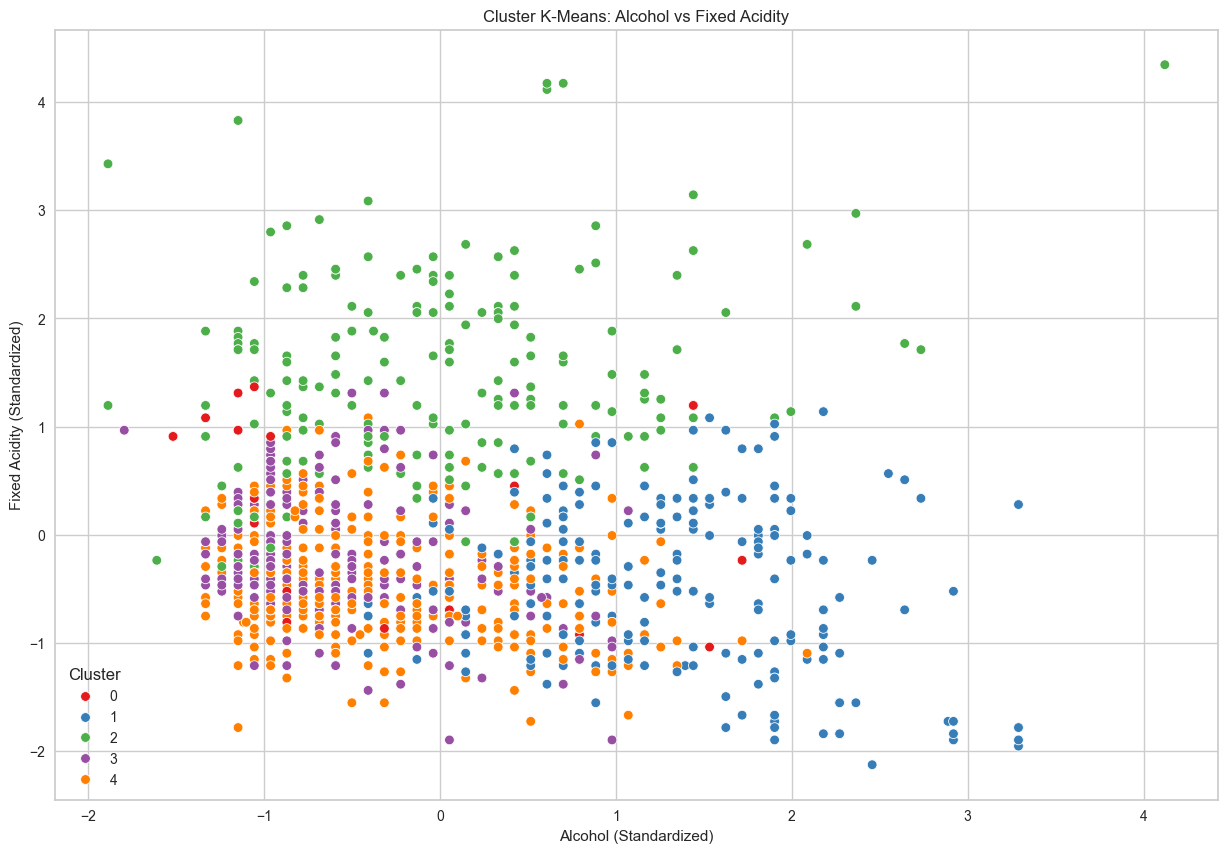

In [105]:
fig, ax = plt.subplots(figsize=(15,10))
sns.scatterplot(data=df_scaled, x='alcohol', y='fixed acidity', hue='Cluster', palette='Set1')
plt.title('Cluster K-Means: Alcohol vs Fixed Acidity')
plt.xlabel('Alcohol (Standardized)')
plt.ylabel('Fixed Acidity (Standardized)')
plt.legend(title='Cluster')
plt.show()

<Axes: xlabel='alcohol', ylabel='fixed acidity'>

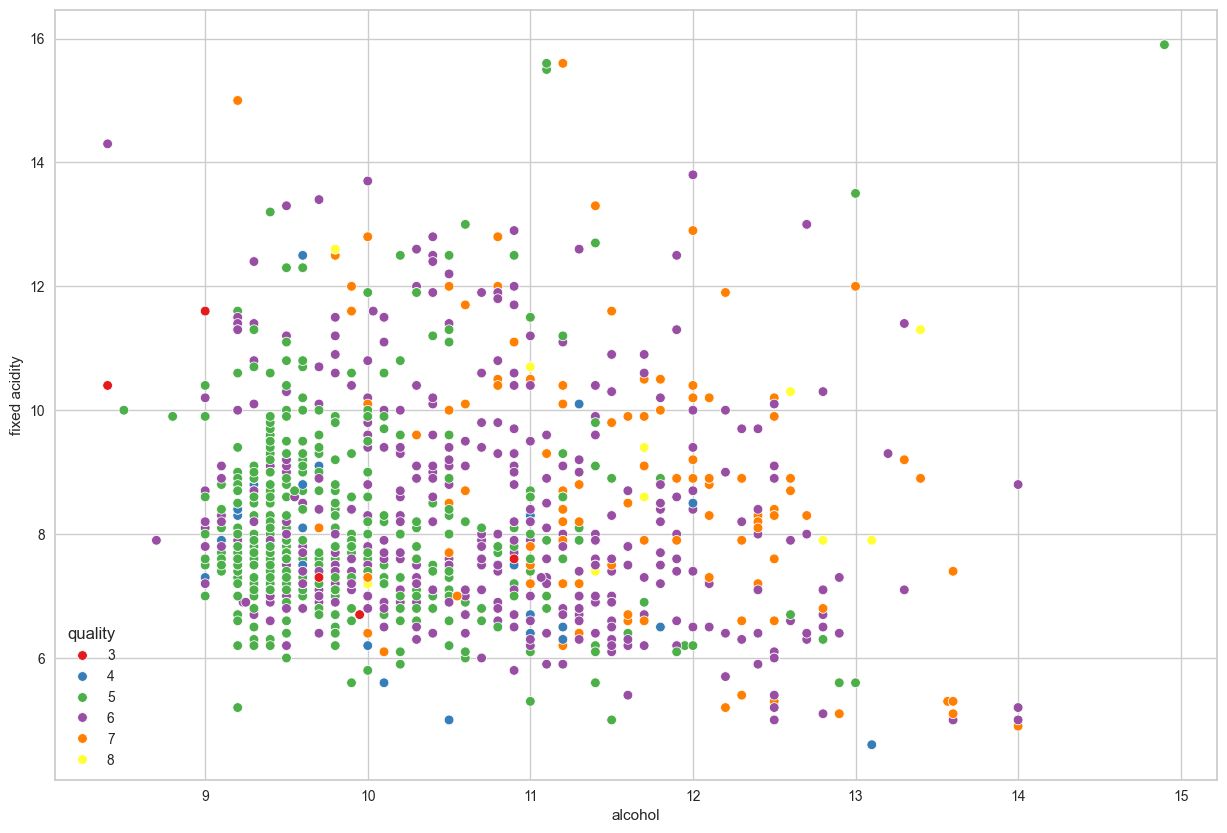

In [106]:
fig, ax = plt.subplots(figsize=(15,10))
sns.scatterplot(data=df, x='alcohol', y='fixed acidity', hue='quality', palette='Set1')

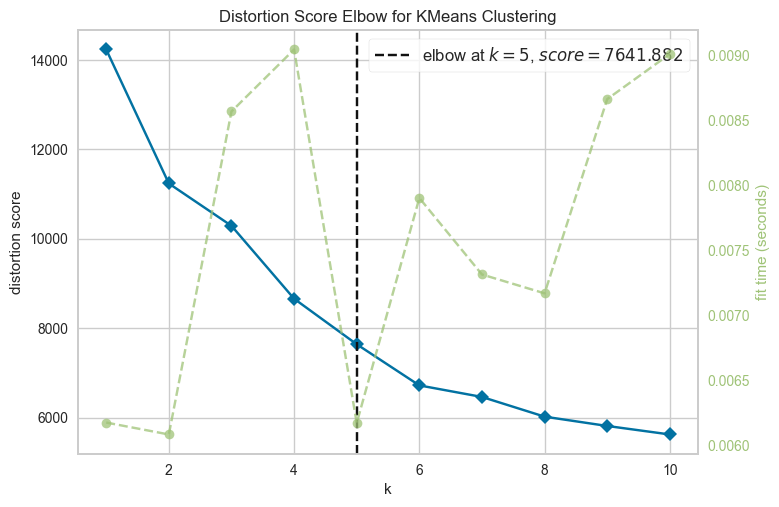

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [107]:
k_means_via = KMeans(random_state=0)
visualizer = KElbowVisualizer(k_means_via, k=(1,11), timings=True, force_model=True)
visualizer.fit(df_scaled.values)
visualizer.show()

In [108]:
kmeans_via = KMeans(n_clusters=5, random_state=0)
kmeans_via.fit(df_scaled.values)

df['cluster_via'] = kmeans_via.labels_
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,cluster_via
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,4
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,2
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


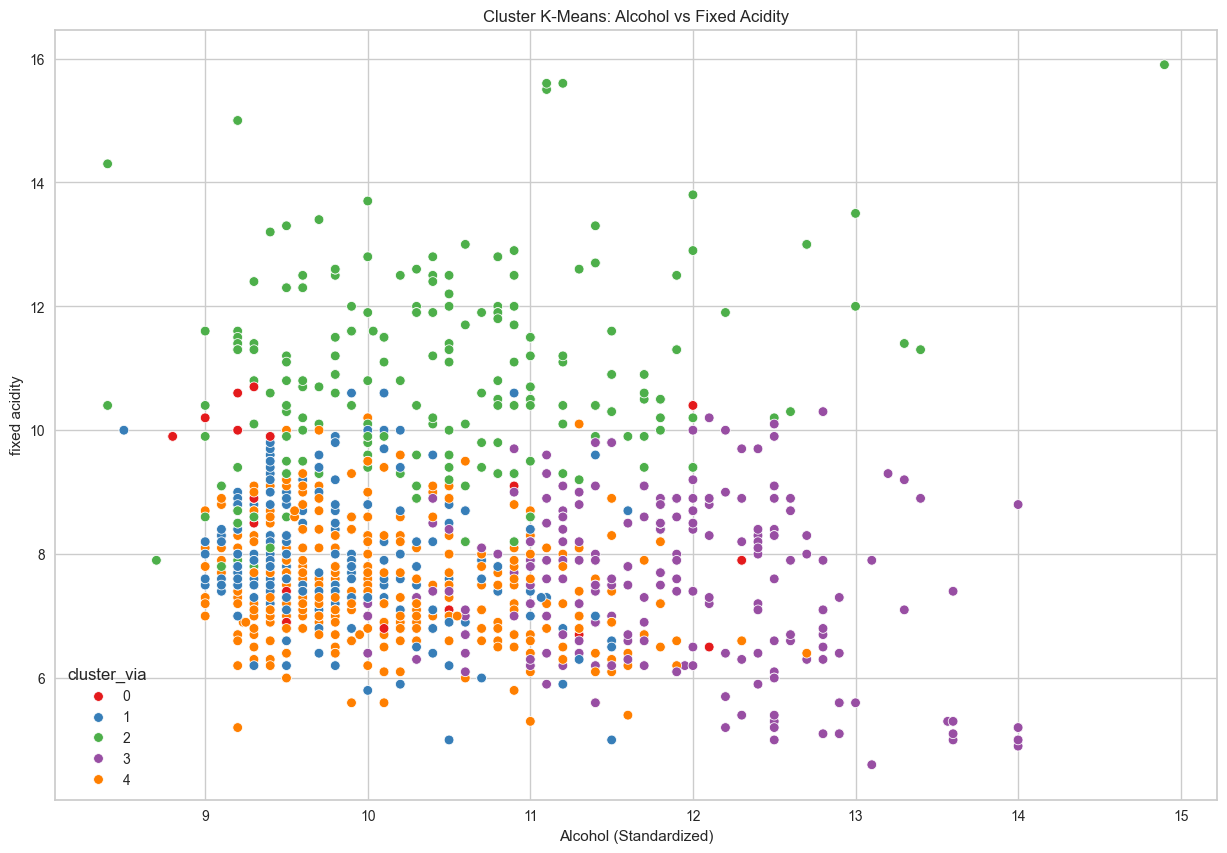

In [109]:
fig, ax = plt.subplots(figsize=(15,10))
sns.scatterplot(data=df, x='alcohol', y='fixed acidity', hue='cluster_via', palette='Set1')
plt.title('Cluster K-Means: Alcohol vs Fixed Acidity')
plt.xlabel('Alcohol (Standardized)')
plt.show()

<Axes: xlabel='alcohol', ylabel='fixed acidity'>

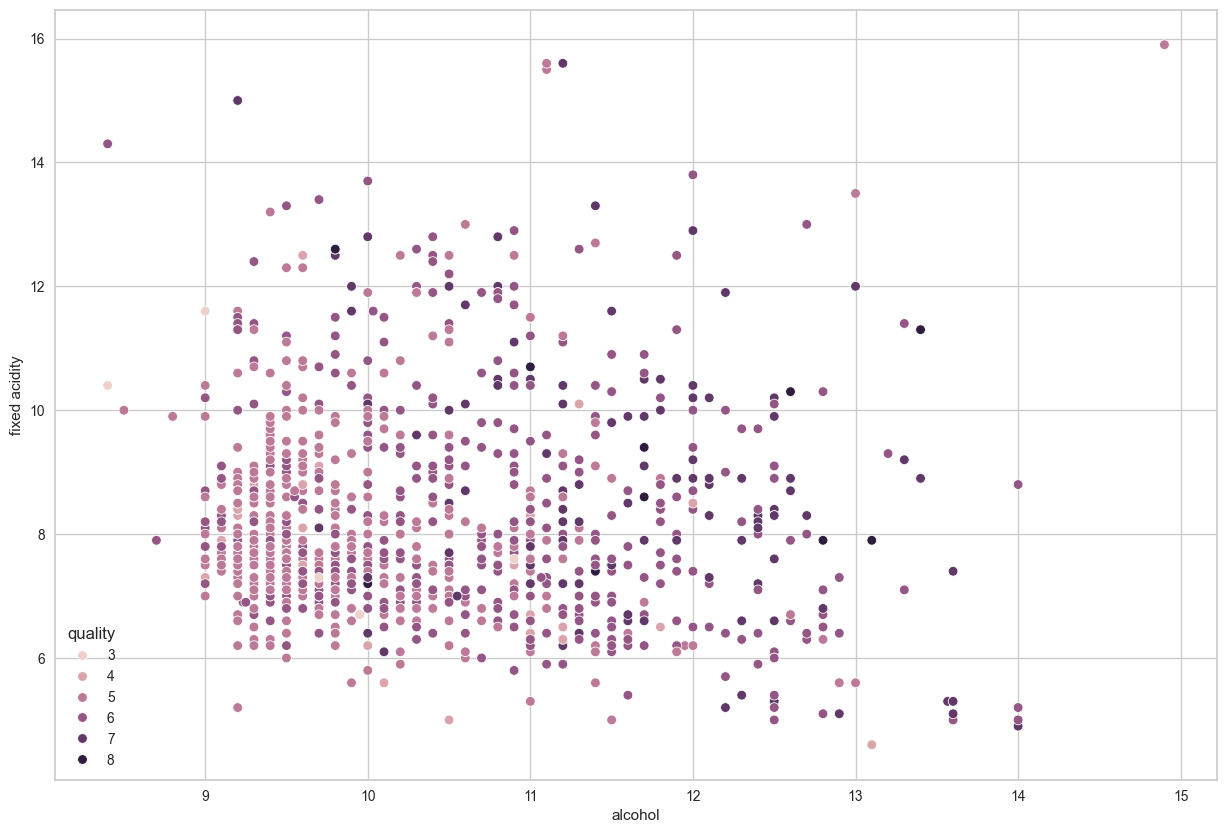

In [110]:
fig, ax = plt.subplots(figsize=(15,10))
sns.scatterplot(data=df, x='alcohol', y='fixed acidity',hue='quality')